# What is a Neural Network?

## The Neuron

Every neuron operates as a computation unit that takes input, multiplies each by its corresponding weight, sums them, and adds a bias term if applicable. This is known as a multiply and accumulate or MAC. Weights are parameters that determine the importance of each input. The training process involves adjusting these weights to minimize the network’s error rate. Neural network accelerators often try to speedup these repetitive MAC operations.

<img src="https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/2025/Shaoni/18-June1/image_2.png" width="500"/>

## Layers

Neural networks organize neurons into layers. The input layer of a neural network receives the raw data inputs (e.g., image pixels or dataset features). Hidden layers transform data through weight and activation function processes. The output layer provides the network’s final prediction through outputs like class labels or numerical values.

<img src="https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/2025/Shaoni/18-June1/image_1.png" width="400"/>

# Convolutional Neural Networks
A convolutional neural network (CNN) takes an input image and classifies it into any of the output classes. Each image passes through a series of different layers – primarily convolutional layers, pooling layers, and fully connected layers. The below picture summarizes what an image passes through in a CNN:

<img src="https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/content/images/2021/05/image-32.png"/>

## Convolutional Layer
The convolutional layer is used to extract features from the input image. It is a mathematical operation between the input image and the kernel (filter). The filter is passed across the image and the output is calculated as follows:

<img src="https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/content/images/2021/08/Convolutional.webp" width="500"/>

Different filters are used to extract different kinds of features. Some common features are given below:

<img src="https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/content/images/2021/05/image-34.png">

# Code Example

PyTorch is a machine learning framework for developing and training models. Here, we will use PyTorch to train a simple model for image classification.

## Importing Libraries

In [26]:
# Load in relevant libraries, and alias where appropriate
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

# Define relevant variables (called hyperparameters) for the ML task
batch_size = 64
num_classes = 10
learning_rate = 0.001
num_epochs = 20

# Device will determine whether to run the training on GPU or CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Loading Data
We will use the CIFAR10 dataset to demonstrate how to train a model. This dataset contains 32×32 RGB images belonging to 10 classes.

Normally, we would also use a validation dataset, but it is not included for simplification.

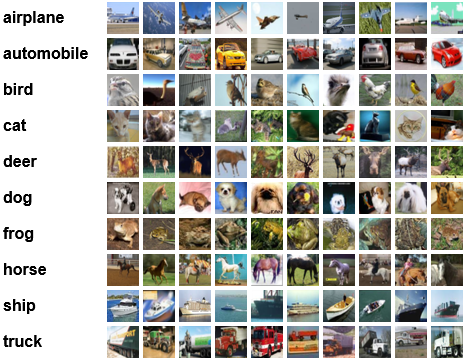

In [27]:
# Use transforms.compose method to reformat images for modeling,
# and save to variable all_transforms for later use
all_transforms = transforms.Compose([transforms.Resize((32,32)),
                                     transforms.ToTensor(),
                                     transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                                                          std=[0.2023, 0.1994, 0.2010])
                                     ])
# Create Training dataset
train_dataset = torchvision.datasets.CIFAR10(root = './data',
                                             train = True,
                                             transform = all_transforms,
                                             download = True)

# Create Testing dataset
test_dataset = torchvision.datasets.CIFAR10(root = './data',
                                            train = False,
                                            transform = all_transforms,
                                            download=True)

# Instantiate loader objects to facilitate processing
train_loader = torch.utils.data.DataLoader(dataset = train_dataset,
                                           batch_size = batch_size,
                                           shuffle = True)


test_loader = torch.utils.data.DataLoader(dataset = test_dataset,
                                           batch_size = batch_size,
                                           shuffle = True)

## Building a Model

We will build a simple CNN model to train on this classification task.

In [23]:
# Creating a CNN class
class ConvNeuralNet(nn.Module):
#  Determine what layers and their order in CNN object
    def __init__(self, num_classes):
        super(ConvNeuralNet, self).__init__()
        self.conv_layer1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)
        self.relu_1 = nn.ReLU()
        self.conv_layer2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3)
        self.relu_2 = nn.ReLU()
        self.max_pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)

        self.conv_layer3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        self.relu_3 = nn.ReLU()
        self.conv_layer4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3)
        self.relu_4 = nn.ReLU()
        self.max_pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)

        self.fc1 = nn.Linear(1600, 128)
        self.relu_5 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    # Progresses data across layers
    def forward(self, x):
        out = self.conv_layer1(x)
        out = self.relu_1(out)
        out = self.conv_layer2(out)
        out = self.relu_2(out)
        out = self.max_pool1(out)

        out = self.conv_layer3(out)
        out = self.relu_3(out)
        out = self.conv_layer4(out)
        out = self.relu_4(out)
        out = self.max_pool2(out)

        out = out.reshape(out.size(0), -1)

        out = self.fc1(out)
        out = self.relu_5(out)
        out = self.fc2(out)
        return out

## Training

Below is a standard training loop. Typically, during training, you would use your validation set to evaluate the progress of the model.

In [24]:
model = ConvNeuralNet(num_classes)
model.to(device)

# Set Loss function with criterion
criterion = nn.CrossEntropyLoss()

# Set optimizer with optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay = 0.005, momentum = 0.9)

total_step = len(train_loader)

# We use the pre-defined number of epochs to determine how many iterations to train the network on
for epoch in range(num_epochs):
# Load in the data in batches using the train_loader object
    for i, (images, labels) in enumerate(train_loader):
        # Move tensors to the configured device
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # RUn on validation

    print('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, loss.item()))

Epoch [1/20], Loss: 2.0556
Epoch [2/20], Loss: 1.7851
Epoch [3/20], Loss: 1.7418
Epoch [4/20], Loss: 1.0691
Epoch [5/20], Loss: 1.5585
Epoch [6/20], Loss: 1.4757
Epoch [7/20], Loss: 0.9665
Epoch [8/20], Loss: 1.5079
Epoch [9/20], Loss: 1.3482
Epoch [10/20], Loss: 1.8050
Epoch [11/20], Loss: 1.3521
Epoch [12/20], Loss: 0.8313
Epoch [13/20], Loss: 0.6764
Epoch [14/20], Loss: 1.0224
Epoch [15/20], Loss: 0.8745
Epoch [16/20], Loss: 1.2449
Epoch [17/20], Loss: 1.1759
Epoch [18/20], Loss: 1.0200
Epoch [19/20], Loss: 0.6348
Epoch [20/20], Loss: 0.9405


## Results

Now that we have trained the model, we can finally evaluate it on the test dataset.

In [25]:
from tqdm import tqdm
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print('Accuracy of the network on the {} test images: {} %'.format(50000, 100 * correct / total))

Evaluating: 100%|██████████| 157/157 [00:02<00:00, 57.89it/s]

Accuracy of the network on the 50000 test images: 68.31 %


Material from:

https://www.digitalocean.com/community/conceptual-articles/neural-network-guide-step-by-step

https://www.digitalocean.com/community/tutorials/writing-cnns-from-scratch-in-pytorch